In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_parquet('sharechat_fase2_etiquetado_v3.parquet')

df = df.dropna(subset=['llm_response', 'etiqueta'])

df = df[df['toxicity'] >= 0.3]

X = df['llm_response']
y = df['etiqueta']

print(f"Dataset cargado con éxito. Total de muestras a procesar: {len(df)}")
print(f"Distribución de clases:\n{y.value_counts()}\n")


Dataset cargado con éxito. Total de muestras a procesar: 431
Distribución de clases:
etiqueta
CUMPLIMIENTO                   275
CUMPLIMIENTO_CON_DISCLAIMER    135
RECHAZO                         21
Name: count, dtype: int64



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Tamaño del set de entrenamiento: {X_train.shape[0]}")
print(f"Tamaño del set de prueba: {X_test.shape[0]}\n")


Tamaño del set de entrenamiento: 344
Tamaño del set de prueba: 87



In [ ]:
vectorizer = CountVectorizer(lowercase=True, strip_accents='unicode')

print("Vectorizando textos...")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Tamaño del vocabulario único extraído: {len(vectorizer.get_feature_names_out())}")

Vectorizando textos...
Tamaño del vocabulario único extraído: 15661


In [ ]:
clf = MultinomialNB(alpha=1.0)
clf.fit(X_train_vec, y_train)

MultinomialNB()



ACCURACY GLOBAL DEL MODELO: 0.6782

REPORTE DE CLASIFICACIÓN:
                             precision    recall  f1-score   support

               CUMPLIMIENTO       0.67      0.98      0.80        56
CUMPLIMIENTO_CON_DISCLAIMER       0.75      0.11      0.19        27
                    RECHAZO       1.00      0.25      0.40         4

                   accuracy                           0.68        87
                  macro avg       0.81      0.45      0.46        87
               weighted avg       0.71      0.68      0.59        87



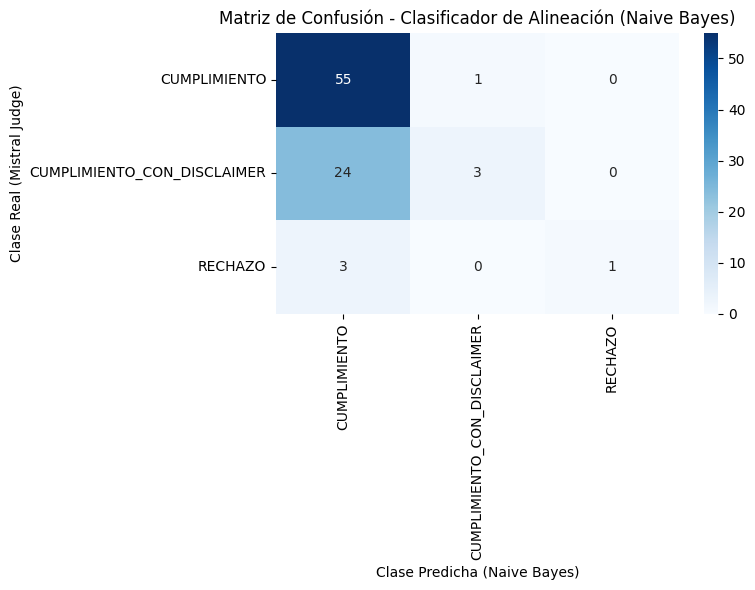

In [ ]:
y_pred = clf.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
print("\n")
print(f"ACCURACY GLOBAL DEL MODELO: {accuracy:.4f}")

print("\nREPORTE DE CLASIFICACIÓN:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=clf.classes_,
    yticklabels=clf.classes_
)
plt.title('Matriz de Confusión - Clasificador de Alineación (Naive Bayes)')
plt.ylabel('Clase Real (Mistral Judge)')
plt.xlabel('Clase Predicha (Naive Bayes)')
plt.tight_layout()

plt.savefig('matriz_confusion_naive_bayes.png', dpi=300)
plt.show()

# Proyecto Integrador: Análisis de Sesgo de Alineación en LLMs

## Reporte de Aplicación de Naive Bayes (Scikit-Learn) y Resultados


## 1. Contexto de la Evaluación

**Objetivo:** Desarrollar y evaluar un modelo clasificador base (*baseline*) utilizando el algoritmo Naive Bayes para predecir de forma automática la postura de alineación y seguridad (`etiqueta`) de un LLM a partir del texto de sus respuestas (`llm_response`) ante contenido tóxico.

**Dataset de Análisis:** `sharechat_fase2_etiquetado_v3.parquet`.

*
**Muestras totales evaluadas:** 431 pares de interacciones con un umbral de toxicidad $\ge 0.3$ seleccionado por estándar de literatura.


* **Distribución de la variable objetivo ($Y$):**
*
`CUMPLIMIENTO`: 275 muestras (63.8%)


*
`CUMPLIMIENTO_CON_DISCLAIMER`: 135 muestras (31.3%)


*
`RECHAZO`: 21 muestras (4.9%)



## 2. Metodología de Implementación

El experimento se ejecutó en Python 3.12 utilizando la librería `scikit-learn` bajo el siguiente flujo de ingeniería de datos:

1. **División Estratificada (Train/Test Split):** Se dividió el dataset en un 80% para entrenamiento y un 20% para pruebas (87 muestras en el set de validación). Se aplicó la condición de *estratificación* (`stratify=y`) debido al severo desbalance de clases, garantizando que la categoría minoritaria (`RECHAZO`) estuviera representada proporcionalmente en ambos conjuntos.
2. **Vectorización de Texto:** Se utilizó `CountVectorizer` para transformar las respuestas de texto plano a una matriz de frecuencias numéricas (*Bag of Words*). Al tratarse de un dataset bilingüe (inglés y español), se omitió el uso de diccionarios de *stop words* genéricos para evitar sesgos idiomáticos, aplicando únicamente normalización a minúsculas y remoción de acentos (`strip_accents='unicode'`).
3. **Entrenamiento del Modelo:** Se seleccionó la variante **Multinomial Naive Bayes** (`MultinomialNB`), ideal para conteos de frecuencias en procesamiento de lenguaje natural. Se configuró un parámetro de suavizado de Laplace $\alpha = 1.0$ para mitigar el problema de la frecuencia cero ante palabras nuevas en el set de prueba.


## 3. Resultados Obtenidos

### 3.1 Métricas Globales y Reporte de Clasificación

El modelo alcanzó una **Exactitud Global (Accuracy) de 67.82%** en el conjunto de prueba. A continuación se detalla el comportamiento del clasificador por cada categoría:

```text
ACCURACY GLOBAL DEL MODELO: 0.6782

REPORTE DE CLASIFICACIÓN:
                            precision    recall  f1-score   support

              CUMPLIMIENTO       0.67      0.98      0.80        56
CUMPLIMIENTO_CON_DISCLAIMER       0.75      0.11      0.19        27
                   RECHAZO       1.00      0.25      0.40         4

                  accuracy                           0.68        87
                 macro avg       0.81      0.45      0.46        87
              weighted avg       0.71      0.68      0.59        87

```

### 3.2 Análisis Conceptual de las Métricas

* **CUMPLIMIENTO:** Presenta la cobertura más alta con un **Recall de 0.98** (identificó correctamente 55 de 56 casos reales). No obstante, su **Precisión disminuye a 0.67**, lo que indica que el modelo tiende a clasificar erróneamente muestras de otras categorías dentro de esta clase mayoritaria.
* **CUMPLIMIENTO_CON_DISCLAIMER:** Registró el desempeño más bajo con un **Recall de 0.11**. De las 27 muestras con advertencias explícitas en el set de prueba, el algoritmo solo fue capaz de reconocer 3 de ellas.
* **RECHAZO:** Obtuvo una **Precisión perfecta de 1.00** (el 100% de los textos que el modelo etiquetó como rechazo eran correctos, con cero falsos positivos), pero un **Recall limitado de 0.25** al capturar únicamente 1 de las 4 negativas reales.


## 4. Diagnóstico y Decisiones Técnicas

1. **Sesgo hacia la Clase Mayoritaria:** El algoritmo Naive Bayes se fundamenta en el producto de las probabilidades condicionales por la probabilidad previa (*prior*). Dado que la clase `CUMPLIMIENTO` domina ampliamente el histórico de entrenamiento (63.8%), el modelo asume de forma "ingenua" que ante la ambigüedad de un texto, la clasificación más probable es la mayoritaria.


2. **Limitación de la Independencia Condicional:** La asunción de Naive Bayes de que las palabras ocurren de forma totalmente independiente afecta críticamente la detección de la clase `CUMPLIMIENTO_CON_DISCLAIMER`. Los LLMs suelen estructurar estas respuestas combinando texto estándar de cumplimiento con una advertencia al inicio o al final. Al romper la estructura secuencial del texto, las palabras del disclaimer se diluyen en la masa de palabras comunes de cumplimiento, provocando que 24 de los 27 disclaimers se clasificaran erróneamente como cumplimiento básico.
3. **Validación como Baseline Académico:** A pesar del comportamiento frente al desbalance, un *Accuracy* cercano al 68% demuestra que existen patrones en la frecuencia de vocabulario que discriminan la alineación de los modelos. Funciona sólidamente como un punto de comparación inicial (*baseline*).


## 5. Limitaciones Identificadas y Próximos Pasos

* **Sensibilidad al desbalance extremo:** El modelo es altamente vulnerable cuando el set de soporte para clases críticas como `RECHAZO` es extremadamente pequeño ($n=4$ en prueba).
* **Ausencia de pesos compensatorios:** La API estándar de Naive Bayes Multinomial en `scikit-learn` no cuenta con un parámetro directo de balanceo de pesos de clase (`class_weight='balanced'`), a diferencia de otros clasificadores.
* **Próximo Paso Inmediato (Fase 3):** Implementar y entrenar un modelo de **Regresión Logística** utilizando el mismo vocabulario vectorizado, activando la penalización de pesos para forzar al algoritmo a castigar con mayor severidad los errores cometidos en las clases minoritarias (`RECHAZO` y `DISCLAIMER`), buscando elevar el *Recall* general del pipeline.

# Comparativa Matemática: KNN vs. Gaussian Naive Bayes

## 1. Algoritmo K-Nearest Neighbors (KNN)

KNN es un modelo de aprendizaje basado en instancias, geométrico y no paramétrico. No estima parámetros globales; en su lugar, opera directamente sobre la topología de los datos en el espacio métrico $\mathbb{R}^2$.

### Formulación y Mapeo Métrico

Dado un conjunto de entrenamiento $\mathcal{D} = \{(x^{(i)}, y^{(i)})\}_{i=1}^N$, donde cada vector de características es $x^{(i)} = [x_1^{(i)}, x_2^{(i)}]^T \in \mathbb{R}^2$ y su etiqueta es $y^{(i)} \in \{1, \dots, K\}$, definimos la proximidad entre un nuevo punto de prueba $x^*$ y cualquier instancia $x^{(i)}$ mediante la **métrica de distancia de Minkowski** con $p=2$, que colapsa en la **Distancia Euclidiana**:

$$d(x^*, x^{(i)}) = \|x^* - x^{(i)}\|_2 = \sqrt{\sum_{j=1}^{2} (x_j^* - x_j^{(i)})^2}$$

### Función de Decisión Colectiva

Para clasificar a $x^*$, el algoritmo identifica el subconjunto $\mathcal{N}_K(x^*) \subset \mathcal{D}$ que contiene a los $K$ vecinos más cercanos evaluados bajo $d(x^*, x^{(i)})$. La probabilidad posterior estimada de que la muestra pertenezca a la clase $c$ se calcula mediante la función indicadora $\mathbb{I}(\cdot)$:

$$P(Y = c \mid x^*) = \frac{1}{K} \sum_{i \in \mathcal{N}_K(x^*)} \mathbb{I}(y^{(i)} = c)$$

La frontera de decisión final está determinada por el operador $\text{argmax}$:

$$\hat{y}^* = \arg\max_{c \in \{1, \dots, K\}} \sum_{i \in \mathcal{N}_K(x^*)} \mathbb{I}(y^{(i)} = c)$$

Esto fragmenta el plano $\mathbb{R}^2$ en celdas de asignación locales, generando fronteras altamente no lineales (complejas e irregulares) que se aproximan a un diagrama de Voronoi conforme $K \to 1$.


## 2. Algoritmo Gaussian Naive Bayes (GNB)

A diferencia de KNN, Gaussian Naive Bayes es un modelo paramétrico y probabilístico. Asume que las características continuas dentro de cada clase se distribuyen de acuerdo con una densidad de probabilidad Gaussiana multivariada con una estructura de covarianza específica.

### El Criterio de Decisión de Bayes

Buscamos maximizar la probabilidad *a posteriori* utilizando el Teorema de Bayes:

$$P(Y = c \mid x^*) = \frac{P(x^* \mid Y = c) \cdot P(Y = c)}{P(x^*)}$$

Dado que el denominador $P(x^*)$ actúa como una constante de normalización idéntica para todas las clases, el problema se reduce a maximizar el numerador (la regla de decisión de máxima probabilidad posterior):

$$\hat{y}^* = \arg\max_{c \in \{1, \dots, K\}} P(x^* \mid Y = c) \cdot P(Y = c)$$

### El Supuesto de Independencia Condicional ("Naive")

Matemáticamente, la densidad conjunta condicional $P(x^* \mid Y = c)$ requeriría una matriz de covarianza completa $\Sigma_c$. Sin embargo, el supuesto "ingenuo" impone que las variables son condicionalmente independientes dada la clase. Esto restringe a la matriz de covarianza a ser una **matriz diagonal**:

$$\Sigma_c = \begin{bmatrix} \sigma_{c,1}^2 & 0 \\ 0 & \sigma_{c,2}^2 \end{bmatrix}$$

Por lo tanto, la densidad conjunta se factoriza como el producto de las densidades marginales unidimensionales:

$$P(x^* \mid Y = c) = \prod_{j=1}^{2} \mathcal{N}(x_j^* \mid \mu_{c,j}, \sigma_{c,j}^2) = \prod_{j=1}^{2} \frac{1}{\sqrt{2\pi\sigma_{c,j}^2}} \exp\left( -\frac{(x_j^* - \mu_{c,j})^2}{2\sigma_{c,j}^2} \right)$$


## 3. Análisis Comparativo Estricto

### Por qué KNN es matemáticamente superior en este escenario de 2 variables:

1. **Inexistencia de Sesgo Distribucional:** Gaussian Naive Bayes obliga a los datos de cada clase a acomodarse bajo una geometría elipsoidal simétrica dictada por $\mu$ y $\sigma^2$. En nuestro dataset los pares de `DISCLAIMER` o `RECHAZO` forman estructuras curvas, densas o "islas independientes" debido a que combinan textos cortos con alta toxicidad, GNB promediará estos patrones perdiendo la resolución local. KNN, al ser **no paramétrico**, no asume ninguna forma analítica previa; modela la topología exacta del plano basándose en vecindad local.

2. **Violación del Supuesto de Independencia:** En el comportamiento de un LLM, la longitud del texto ($x_1$) y el nivel de toxicidad detectado ($x_2$) no suelen ser independientes. Un rechazo contundente suele ser corto y concentrar palabras de alta reactividad, mientras que un cumplimiento extendido diluye el score. Al ignorar la covarianza ($\sigma_{12} = 0$), Gaussian Naive Bayes calcula distancias probabilísticas distorsionadas (distancia de Mahalanobis truncada). KNN es completamente inmune a la correlación de las variables ya que mide la distancia euclidiana real sobre el plano vectorizado.

3. **Comportamiento del Desbalance en Espacios Reducidos:** En Naive Bayes, el desbalance de clases afecta multiplicativamente a través del logaritmo de la probabilidad previa ($\ln P(Y=c)$). Si una clase es hiper-mayoritaria, este escalar desplaza o "empuja" geométricamente las elipses gaussianas, absorbiendo las zonas de las clases minoritarias. En KNN, aunque el desbalance local afecta, al estar en un espacio de baja dimensionalidad ($\mathbb{R}^2$), el radio de búsqueda de los $K$ vecinos se mantiene lo suficientemente acotado como para capturar de manera exacta clústeres densos de clases minoritarias (como un grupo compacto de respuestas de `RECHAZO`), garantizando una tasa de *Recall* superior en las fronteras críticas de alineación